In this notebook, we will use sklearn's LASSO for feature selection. This serves to simplify our dataset and improve interpretability.

In [1]:
#dependencies
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from scipy.optimize import minimize # for ensemble weight optimization
#for feature selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, LassoCV, LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

In [31]:
# download LightGBM package
!pip install lightgbm

In [36]:
# download catboost package
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.8/28.8 MB 27.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 34.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [catboost]3/4 [catboost]


In [2]:
# LGBM & catboost dependencies
import lightgbm as lgbm
from catboost import CatBoostRegressor
#from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV

In [4]:
# function for model evalaution in both log-price 'units' as well as natural units (USD dollar) 
def evaluate_model(y_true, y_pred_log):

    # TRUE VALUES IN LOG SPACE
    y_true_log = np.log1p(y_true)

    # BACK TRANSFORM PREDICTIONS
    y_pred = np.expm1(y_pred_log)

    # --- METRICS IN LOG SPACE ---
    rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    mae_log = mean_absolute_error(y_true_log, y_pred_log)
    r2_log = r2_score(y_true_log, y_pred_log)
    mape_log = mean_absolute_percentage_error(y_true_log, y_pred_log)

    # --- METRICS IN PRICE SPACE ---
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)

    print("------ LOG METRICS ------")
    print("RMSE_log:", rmse_log)
    print("MAE_log:", mae_log)
    print("R2_log:", r2_log)
    print("MAPE_log:", mape_log)

    print("\n------ PRICE METRICS ($) ------")
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("R2:", r2)
    print("MAPE:", mape)

    return

In [6]:
train.columns

Index(['sale_date', 'maker_id', 'maker_name', 'type', 'city_maker',
       'auction_house', 'lot', 'bold_currency', 'Year', 'Month', 'Day',
       'cpi_usd', 'cpi_gbp', 'cpi_eur', 'gbp_usd_x', 'eur_usd',
       'price_usd_real', 'SP500_real', 'SP500_30d_ret', 'SP500_90d_ret',
       'SP500_252d_ret', 'SP500_vol_30d', 'SP500_vol_90d', 'SP500_vol_252d',
       'SP500_ma50', 'SP500_ma200', 'SP500_trend_ratio', 'gbp_usd_y',
       'gbp_90d_change', 'gbp_vol_30d', '10y_yield_pc', '10y_yield_90d_change',
       'MCI', 'real_price_gold', 'country_iso1', 'admin1_name', 'admin2_name',
       'role', 'maker_last_name', 'birth_cent'],
      dtype='object')

In [48]:
train = pd.read_csv("train.csv")
val = pd.read_csv("val.csv")

#drop unnecessary features
UnneededFeatures = ['sale_date.1', 'maker_name_maker', 'is_ambiguous', 'candidate_count', 'location_filled', 'date', 'usd', 'gbp', 'eur', 'candidate_count']
UnneededFeatures += ['maker_name', 'lot', 'Day', 'gbp_usd_y', 'role']
train = train.drop(columns = UnneededFeatures)
valid = val.drop(columns = UnneededFeatures)

X_train = train.iloc[:, train.columns != 'price_usd_real']
X_valid = valid.iloc[:, train.columns != 'price_usd_real']
Y_train = train.iloc[:, train.columns == 'price_usd_real']
Y_valid = valid.iloc[:, train.columns == 'price_usd_real']

In [58]:
#log transforming target
train['log_price'] = np.log1p(train['price_usd_real'])
t=train.groupby('type')['log_price']

#groups each instrument type of the train set by its mean/median price
type_mean = train.groupby('type')['log_price'].mean()  
type_median = train.groupby('type')['log_price'].median()

type_mean.head()

type
Bass          9.835546
Bass Bow      7.830970
Bass Viol    11.087919
Cello        10.124304
Cello Bow     8.540933
Name: log_price, dtype: float64

We will temporarily create two new columns in the validation set to predict the price of each instrument sale using our means/medians above.

In [53]:
#check for missing values
print(X_train['type'].isna().any())
print(X_valid['type'].isna().any())

#creating new columns
valid['type_mean']= valid['type'].map(type_mean)
valid['type_median'] = valid['type'].map(type_median)
valid.head()

False
False


,sale_date,maker_id,type,city_maker,auction_house,bold_currency,Year,Month,cpi_usd,cpi_gbp,...,10y_yield_90d_change,MCI,real_price_gold,country_iso1,admin1_name,admin2_name,maker_last_name,birth_cent,type_mean,type_median
0,2000-02-14,2827,Violin,Paris,Phillip's,gbp,2000,2,0.522057,0.534901,...,0.00505,-6.037718,588.0587,FR,Île-de-France,Paris,Collin-Mézin,20.0,9.159512,8.991187
1,1995-11-14,356,Violin,Mirecourt,Bonhams,gbp,1995,11,0.472249,0.493020,...,-0.00120,4.018622,815.9887,FR,Grand Est,Vosges,Thibouville-Lamy,19.0,9.159512,8.991187
2,2008-10-07,185,Cello,Mantua,Sotheby's,gbp,2008,10,0.665862,0.641440,...,-0.00420,-4.978523,1331.5068,IT,Lombardy,Provincia di Mantova,Gadda,20.0,10.124304,10.062779
3,1993-05-23,1327,Viola,Vienna,Skinner,usd,1993,5,0.443349,0.467303,...,-0.00440,1.206404,851.0234,AT,Vienna,Wien Stadt,Huber,18.0,9.097133,9.065886
4,2010-10-10,524,Violin,Cremona,Skinner,usd,2010,10,0.672436,0.665687,...,-0.00790,3.251219,2002.1250,IT,Lombardy,Provincia di Cremona,Pedrazzini,19.0,9.159512,8.991187


# Model 0.1: Mean & Median Baseline Models

In [55]:
#evaluating base model
print("Base model: Predicting prices by mean and median of train set \n")
print("Mean")
evaluate_model(Y_valid, valid['type_mean'])

print("\n Median")
evaluate_model(Y_valid, valid['type_median'])

Base model: Predicting prices by mean and median of train set 

Mean
------ LOG METRICS ------
RMSE_log: 1.285456313665743
MAE_log: 0.988432919402884
R2_log: 0.10001861657415356
MAPE_log: 0.11279419733674426

------ PRICE METRICS ($) ------
RMSE: 125935.18437162781
MAE: 22152.072084267635
R2: -0.014001477146394548
MAPE: 1.5594670219204665

 Median
------ LOG METRICS ------
RMSE_log: 1.2931641897639936
MAE_log: 0.9841738236638584
R2_log: 0.0891932891990842
MAPE_log: 0.11087921033874927

------ PRICE METRICS ($) ------
RMSE: 126116.55690583902
MAE: 22118.01709392209
R2: -0.016924321211996718
MAPE: 1.3814586533054676


It is clear that predicting fine string instrument prices based on their instrument type alone is really unsuccessful because there are so many charactersitics/features that are not accounted for in this way, such as the maker who plays a hige role for the price, the instrument age, its condition, provenence and many more factors.

# Mode 0.2: Local Mean Model

In [56]:
def fit_baseline(train, min_count=1):
    """
    Compute mean prices on the training set.
    Returns three objects: maker_type_mean, type_mean, global_mean.
    min_count : minimum number of sales required to use the maker+type mean.
    """
    maker_type_stats = (
        train.groupby(['maker_id', 'type'])['log_price']
        .agg(['mean', 'count'])
    )
    maker_type_mean = (
        maker_type_stats[maker_type_stats['count'] >= min_count]['mean']
        .to_dict()
    )
    type_mean = t.mean().to_dict()

    return maker_type_mean, type_mean


def predict_baseline(df, maker_type_mean, type_mean):
    """
    For each row:
      1. Use the (maker_id, type) mean if >= min_count sales in train
      2. Otherwise use the type mean
    """
    preds = []
    for _, row in df.iterrows():
        key = (row['maker_id'], row['type'])
        if key in maker_type_mean:
            preds.append(maker_type_mean[key])
        elif row['type'] in type_mean:
            preds.append(type_mean[row['type']])
    return np.array(preds)

In [59]:
#  the prediction 
maker_type_mean, type_mean = fit_baseline(train)

y_pred = predict_baseline(valid, maker_type_mean, type_mean)

In [60]:
evaluate_model(Y_valid, y_pred)

------ LOG METRICS ------
RMSE_log: 0.7235277112568363
MAE_log: 0.5342694865235458
R2_log: 0.7148789897186255
MAPE_log: 0.06271652820481852

------ PRICE METRICS ($) ------
RMSE: 90880.64805801703
MAE: 13631.308149991059
R2: 0.47193515802333164
MAPE: 0.7896261917559948


In [61]:
#dropping columns we created for base model
valid = valid.drop(columns = ['type_mean', 'type_median'])
train = train.drop(columns = ['log_price'])

In [62]:
#collect categorical features
CategoricalCols = train.select_dtypes(include=["object", "bool"]).columns.tolist()

for x in CategoricalCols:
    print(f"{x} has {train[x].nunique()} unique values")

sale_date has 941 unique values
type has 14 unique values
city_maker has 628 unique values
auction_house has 27 unique values
bold_currency has 3 unique values
country_iso1 has 37 unique values
admin1_name has 164 unique values
admin2_name has 371 unique values
maker_last_name has 2164 unique values


We will consider features with less that 20 unique values as "low cardinality", and the rest as "high cardinality".

In [63]:
LowCardCols = ["type", "bold_currency"]
#HighCardCols = ["sale_date", "maker_name", "city_maker", "auction_house", "lot", "country_iso1", "admin1_name", "admin2_name", "role", "maker_last_name"]
HighCardCols = ["sale_date", "maker_name", "city_maker", "auction_house", "country_iso1", "admin1_name", "admin2_name", "maker_last_name"]

In [64]:
#log transforming economic features
LogColumns = ['real_price_gold', 'SP500_real']

In [65]:
#features with numerical values
numberdtype = X_train.select_dtypes(include=[np.number]).columns.tolist()

#prevent overlap
NumericalCols = list( set(numberdtype) - set(LogColumns))


In [66]:
#impute with median and scale numerical columns
Numerical_transformer = Pipeline([
     ('imputer', SimpleImputer(strategy='median')), 
     ('scaler', StandardScaler() )
     ])

#impute and one hot encode low cardinality columns
OneHot_transformer = Pipeline([
('imputer', SimpleImputer(strategy='constant', fill_value="other" )),
('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

#impute and target encode high cardinality columns
Target_transformer = Pipeline([
('imputer', SimpleImputer(strategy='constant', fill_value="other")),
('target', TargetEncoder() )
])

#transform "log columns"
log_transformer = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p, feature_names_out="one-to-one") ),
    ('scale', StandardScaler())
])



In [67]:
#this will apply our transformations
preprocessor = ColumnTransformer(
    transformers =[
        ('lognum', log_transformer, LogColumns),
        ('lowcard', OneHot_transformer, LowCardCols ),
        ('highcard', Target_transformer, HighCardCols ) ,
        ('num', Numerical_transformer, NumericalCols )],
        remainder = 'passthrough',
        sparse_threshold=0
)

# Model 1: Lasso-Regression

We can fit our data to a lasso regression pipeline with the same transformed columns. We can use this with the goal of feature selection and determining feature importance.

In [26]:
#lassocv with 10 cross validation folds
pipeline_lasso = Pipeline([
    ('preprocessor', preprocessor),
    ('lasso', LassoCV(cv=10))
])


lr = pipeline_lasso.fit(X_train,np.log1p(Y_train.values.ravel()))

In [27]:
#predictions in log prices
lasso_pred = lr.predict(X_valid)

print("Lassocv model evaluation: \n")
evaluate_model(Y_valid, lasso_pred)


#gives the optimal penalty determined by lassocv
optimal_alpha = pipeline_lasso.named_steps['lasso'].alpha_
print("\nOptimal alpha:", f"{optimal_alpha:.5f}")


Lassocv model evaluation: 

------ LOG METRICS ------
RMSE_log: 0.6614289048918677
MAE_log: 0.5041537073554309
R2_log: 0.7617212997613172
MAPE_log: 0.058488062043738596

------ PRICE METRICS ($) ------
RMSE: 99234.9162158688
MAE: 14065.373796506776
R2: 0.3703873607858278
MAPE: 0.6549276325530498

Optimal alpha: 0.00125


In [28]:
#recovers the features transformed in the pipeline
preprocessor_lasso = pipeline_lasso.named_steps['preprocessor']
feature_names = preprocessor.get_feature_names_out()

In [29]:
#gives coefficients used for each feature in regression
lasso_step = lr.named_steps['lasso']
coefficients = lasso_step.coef_

zerofeatures = []
nonzerofeatures = []

#setting a lower bound for a coefficient to be considered "nonzero"
epsilon = 1e-5

for i in range(len(feature_names)):
    if abs(coefficients[i]) < epsilon:
        zerofeatures.append(feature_names[i])
    else: nonzerofeatures.append(feature_names[i])

#the features with a coefficient of zero
for x in zerofeatures:
    print(x)


lowcard__type_Bass
lowcard__type_Bass Bow
lowcard__type_Bass Viol
lowcard__type_Miscellaneous
lowcard__type_Tenor Viol
lowcard__type_Treble Viol
lowcard__type_Viola Bow
lowcard__type_Viola d'Amore
lowcard__type_Violin
lowcard__bold_currency_usd
highcard__country_iso1
num__Year
num__SP500_30d_ret
num__gbp_vol_30d
num__SP500_vol_30d
num__cpi_usd
num__SP500_trend_ratio
num__SP500_ma200


In [31]:
# feature and corresponding coefficient
lasso_coeffs = pd.DataFrame(index=feature_names, columns=['Lasso_Coeffs'])
lasso_coeffs.Lasso_Coeffs = coefficients
print('Non-zero Coefficient Features:')
lasso_coeffs.loc[nonzerofeatures, :]

Non-zero Coefficient Features:


,Lasso_Coeffs
lognum__real_price_gold,-0.019426
lognum__SP500_real,0.004667
lowcard__type_Cello,0.794087
lowcard__type_Cello Bow,-0.020191
lowcard__type_Small Violin,-0.276956
lowcard__type_Viola,0.037277
lowcard__type_Violin Bow,-0.116283
lowcard__bold_currency_eur,-0.006611
lowcard__bold_currency_gbp,0.027877
highcard__sale_date,0.359694


In [32]:
#shows the different alphas selected by lassocv
alphas =lasso_step.alphas_
print(alphas)


[1.25152508 1.16717647 1.08851269 1.01515057 0.94673282 0.8829262
 0.82341993 0.76792418 0.71616866 0.66790129 0.62288698 0.58090648
 0.54175533 0.50524283 0.47119116 0.43943445 0.40981804 0.38219767
 0.35643883 0.33241605 0.31001232 0.28911852 0.2696329  0.25146055
 0.23451295 0.21870756 0.2039674  0.19022068 0.17740045 0.16544425
 0.15429386 0.14389497 0.13419693 0.12515251 0.11671765 0.10885127
 0.10151506 0.09467328 0.08829262 0.08234199 0.07679242 0.07161687
 0.06679013 0.0622887  0.05809065 0.05417553 0.05052428 0.04711912
 0.04394344 0.0409818  0.03821977 0.03564388 0.0332416  0.03100123
 0.02891185 0.02696329 0.02514605 0.02345129 0.02187076 0.02039674
 0.01902207 0.01774004 0.01654442 0.01542939 0.0143895  0.01341969
 0.01251525 0.01167176 0.01088513 0.01015151 0.00946733 0.00882926
 0.0082342  0.00767924 0.00716169 0.00667901 0.00622887 0.00580906
 0.00541755 0.00505243 0.00471191 0.00439434 0.00409818 0.00382198
 0.00356439 0.00332416 0.00310012 0.00289119 0.00269633 0.00251

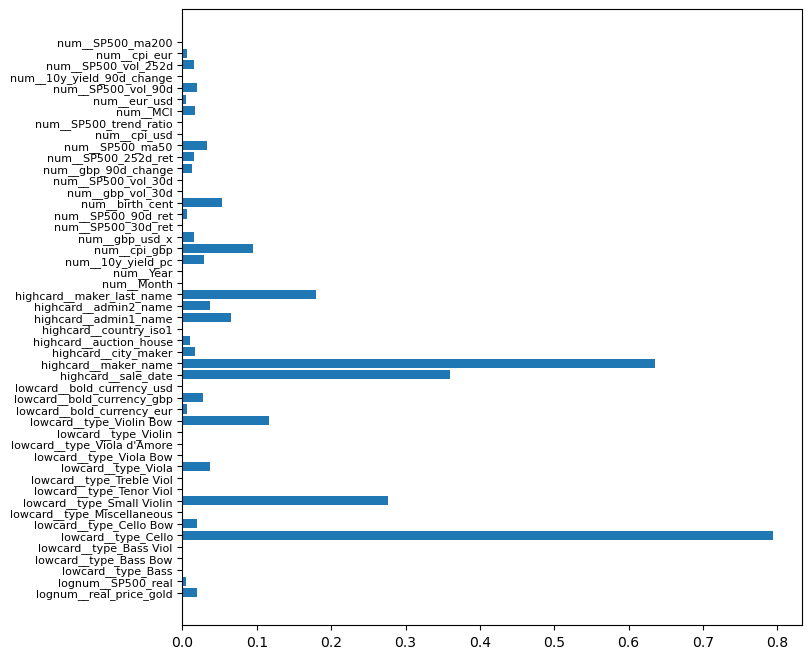

In [33]:
plt.figure(figsize=(8,8))

abs_coefficients = [abs(x) for x in coefficients]
plt.barh(feature_names, abs_coefficients)
plt.tight_layout
plt.yticks(fontsize=8)
plt.show()

Here we see that many different features all carry predictive power: the instrument type is especially crucial for price prediction bt so is the instrument maker. In addition to that the enhanced features that were created especially for this data set seem to have good predictive power. Those are the economic features based, e.g., on the stock market indices, as well as the geographical information inferred for each instrument.

# Model 2: Random Forest

In [34]:
#creates a pipeline object
pipeline_randomforest = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', RandomForestRegressor(n_estimators=200, random_state=0))
])
#fits our data to the pipeline/model with log transformed target
rf = pipeline_randomforest.fit(X_train,np.log1p(Y_train))

forest_pred_log = rf.predict(X_valid)

evaluate_model(Y_valid, forest_pred_log)

/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/miniconda3/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


------ LOG METRICS ------
RMSE_log: 0.6257691271112914
MAE_log: 0.4738464698435766
R2_log: 0.7867214651701127
MAPE_log: 0.05503795588417701

------ PRICE METRICS ($) ------
RMSE: 81249.92934985909
MAE: 12228.769221954923
R2: 0.5779242439868504
MAPE: 0.6033967078151553


# Model 3: LightGBM

Define the Model with default parameters.

In [35]:
lgbm_model = lgbm.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.02,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose = -1
)

In [36]:
pipeline_lgbm = Pipeline([
    ('preprocessor', preprocessor),
    ('model', lgbm_model)])

Use cross-validation to find the best model via a grid-search.

In [37]:
'''param_grid = {
    "model__num_leaves": [80, 100, 120, 140],
    "model__learning_rate": [0.005, 0.007, 0.009],
    "model__n_estimators": [800, 900, 1000],
    "model__max_depth": [-1]
}'''
# this parameter grid has already been narrowed down in many iterations of running the algo
param_grid = {
    "model__num_leaves": [62, 63, 64], # best 63
    "model__learning_rate": [0.01, 0.011], # best 0.011
    "model__n_estimators": [2300, 2500, 2700, 2900], # best 2300
    "model__max_depth": [-1]
}


search_lgbm = RandomizedSearchCV(
    pipeline_lgbm,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_iter=20,
    n_jobs=-1,
    verbose=1
)

In [38]:
search_lgbm.fit(X_train, np.log1p(Y_train.values.ravel()))

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13

,estimator,Pipeline(step...verbose=-1))])
,param_distributions,"{'model__learning_rate': [0.01, 0.011], 'model__max_depth': [-1], 'model__n_estimators': [2300, 2500, ...], 'model__num_leaves': [62, 63, ...]}"
,n_iter,20
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [65]:
best_lgbm = search_lgbm.best_estimator_
print(search_lgbm.best_params_)

{'model__num_leaves': 63, 'model__n_estimators': 2300, 'model__max_depth': -1, 'model__learning_rate': 0.011}


In [39]:
best_lgbm = search_lgbm.best_estimator_
print(search_lgbm.best_params_)

{'model__num_leaves': 63, 'model__n_estimators': 2300, 'model__max_depth': -1, 'model__learning_rate': 0.01}


### Prediction

In [40]:
y_pred_log_lgbm = best_lgbm.predict(X_valid)
#y_pred_lgbm = np.expm1(y_pred_log_lgbm)

/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [67]:
evaluate_model(Y_valid, y_pred_log_lgbm)

------ LOG METRICS ------
RMSE_log: 0.5915523073845861
MAE_log: 0.44952667337148716
R2_log: 0.8094077715696875
MAPE_log: 0.05224199163204214

------ PRICE METRICS ($) ------
RMSE: 79760.08948291995
MAE: 11785.950275118308
R2: 0.5932611203050077
MAPE: 0.5660110600022191


In [41]:
evaluate_model(Y_valid, y_pred_log_lgbm)

------ LOG METRICS ------
RMSE_log: 0.6011523570210023
MAE_log: 0.45635659533935524
R2_log: 0.8031714962709248
MAPE_log: 0.0529720375616172

------ PRICE METRICS ($) ------
RMSE: 81246.8103462419
MAE: 11993.900479999475
R2: 0.5779566484591341
MAPE: 0.5712130657697254


# Model 4: CatBoost

In [42]:
y_train_log = np.log1p(Y_train.squeeze())
y_valid_log = np.log1p(Y_valid.squeeze())

cat_model = CatBoostRegressor(
    loss_function='RMSE',
    random_seed=42,
    verbose=0)

pipeline_cat = Pipeline([("preprocessor", preprocessor), ("model", cat_model)])

'''param_dist = {
    "model__iterations": [2000,3000,4000], #best was 2000
    "model__learning_rate": [0.01,0.02,0.03], #best was 0.03
    "model__depth": [10, 12, 15], #best was 10
    "model__l2_leaf_reg": [20], #best was 20
    "model__min_data_in_leaf": [5], #best was 5
}'''
param_dist = {
    "model__iterations": [2000], #best was 2000
    "model__learning_rate": [0.03], #best was 0.03
    "model__depth": [10], #best was 10
    "model__l2_leaf_reg": [20], #best was 20
    "model__min_data_in_leaf": [5], #best was 5
}

search_cat = RandomizedSearchCV(
    pipeline_cat,
    param_distributions=param_dist,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_iter=20,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

In [43]:
search_cat.fit(X_train, y_train_log)

best_cat = search_cat.best_estimator_
print("Best CatBoost params:", search_cat.best_params_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


/opt/miniconda3/lib/python3.13/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=20. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best CatBoost params: {'model__min_data_in_leaf': 5, 'model__learning_rate': 0.03, 'model__l2_leaf_reg': 20, 'model__iterations': 2000, 'model__depth': 10}


In [51]:
y_pred_log_cat = best_cat.predict(X_valid)

evaluate_model(Y_valid.squeeze(), y_pred_log_cat)

------ LOG METRICS ------
RMSE_log: 0.5905759283339266
MAE_log: 0.44837313222093783
R2_log: 0.8100364114458073
MAPE_log: 0.05210475056832776

------ PRICE METRICS ($) ------
RMSE: 86252.88156355235
MAE: 11872.476555485136
R2: 0.5243454569859778
MAPE: 0.5597352579985887


In [44]:
y_pred_log_cat = best_cat.predict(X_valid)

evaluate_model(Y_valid.squeeze(), y_pred_log_cat)

------ LOG METRICS ------
RMSE_log: 0.5992174716203997
MAE_log: 0.4539605339603185
R2_log: 0.8044364924133159
MAPE_log: 0.05278867290769854

------ PRICE METRICS ($) ------
RMSE: 88871.44125812525
MAE: 12081.631821381367
R2: 0.4950261722760205
MAPE: 0.5732310745603786


# Model(s) 5: Ensemble Method
In this section we will combine (in various ways) the predictions of the three performant model (Random Forest, LGBM, CatBoost) in order to determine whether a combination of the models performs better than each one alone.

In [45]:
# stack all the predictions that ought be used in the ensemble
X_ensemble = np.column_stack([
    forest_pred_log,
    y_pred_log_lgbm,
    y_pred_log_cat
])

## Naive Ensemble

In [70]:
y_pred_avg = X_ensemble.mean(axis=1)

In [72]:
evaluate_model(Y_valid, y_pred_avg)

------ LOG METRICS ------
RMSE_log: 0.5920603811129262
MAE_log: 0.4490121663130108
R2_log: 0.80908023844111
MAPE_log: 0.05219993326280891

------ PRICE METRICS ($) ------
RMSE: 81162.83645121651
MAE: 11701.314874263773
R2: 0.5788286164501342
MAPE: 0.5631582579887113


## Weighted Ensemble
We find the optimal ensemble weights via optimization with a RMSE loss for weighting the models linearly, which is implemented through an additional Ridge Regression. This means the ensemble prediction is a omptimized linear combination of the 3 input model predictions. 

In [73]:
def rmse_loss(weights):
    weights = weights / weights.sum()  # normalize weights, such that they sum to 1
    y_pred = np.dot(X_ensemble, weights)
    return np.sqrt(mean_squared_error(y_valid_log, y_pred))

# initial equal weights
init_weights = np.array([1/3, 1/3, 1/3])

# constraint: weights sum to 1
constraints = {'type': 'eq', 'fun': lambda w: w.sum() - 1}

# bounds: weights between 0 and 1
bounds = [(0, 1)] * 3

result = minimize(rmse_loss, init_weights, bounds=bounds, constraints=constraints) # scipy numerical optimizer

optimal_weights = result.x / result.x.sum()
print("Optimal weights:", optimal_weights)

Optimal weights: [0.        0.4866936 0.5133064]


In [90]:
meta_model = Ridge(alpha=1)
meta_model.fit(X_ensemble, y_valid_log)

y_pred_stacked = meta_model.predict(X_ensemble)

print("Stacking coefficients:", meta_model.coef_)

Stacking coefficients: [-0.00881622  0.45588906  0.56591219]


In [91]:
evaluate_model(Y_valid, y_pred_stacked)

------ LOG METRICS ------
RMSE_log: 0.5879901174371883
MAE_log: 0.4460433732295467
R2_log: 0.8116962642206067
MAPE_log: 0.051848466549446595

------ PRICE METRICS ($) ------
RMSE: 81476.44131411426
MAE: 11661.948581451665
R2: 0.5755676025612575
MAPE: 0.5604766606006077


# Error Analysis

In [68]:
def error_analysis_report(
    X,
    y_true_raw,
    y_pred_log,
    location_col="location_filled",
    type_col="type",
    country_col="country_iso1",
    price_outlier_q=0.99,
    error_outlier_q=0.95,
    min_group_size=20,
    top_n_countries=15,
    top_n_worst_rows=25
):
    """
    Analyse d'erreur pour un modèle entraîné sur log1p(price).
    """

    X = X.copy().reset_index(drop=True)
    y_true_raw = pd.Series(np.asarray(y_true_raw).reshape(-1), name="y_true_raw").reset_index(drop=True)
    y_pred_log = pd.Series(np.asarray(y_pred_log).reshape(-1), name="y_pred_log").reset_index(drop=True)

    if not (len(X) == len(y_true_raw) == len(y_pred_log)):
        raise ValueError("X, y_true_raw, et y_pred_log doivent avoir la même longueur.")

    df = X.copy()
    df["y_true_raw"] = y_true_raw
    df["y_true_log"] = np.log1p(y_true_raw.clip(lower=0))
    df["y_pred_log"] = y_pred_log
    df["y_pred_raw"] = np.expm1(y_pred_log)

    # Calcul des erreurs
    df["error_raw"] = df["y_pred_raw"] - df["y_true_raw"]
    df["abs_error_raw"] = df["error_raw"].abs()

    denom = np.maximum(df["y_true_raw"].to_numpy(), 1.0)
    df["pct_error"] = 100.0 * df["error_raw"] / denom
    df["abs_pct_error"] = df["pct_error"].abs()

    df["error_log"] = df["y_pred_log"] - df["y_true_log"]
    df["abs_error_log"] = df["error_log"].abs()

    # Détection des outliers
    price_cut = df["y_true_raw"].quantile(price_outlier_q)
    err_cut = df["abs_error_log"].quantile(error_outlier_q)

    df["price_outlier"] = df["y_true_raw"] >= price_cut
    df["error_outlier"] = df["abs_error_log"] >= err_cut

    df["outlier_bucket"] = np.select(
        [
            df["price_outlier"] & df["error_outlier"],
            df["price_outlier"] & ~df["error_outlier"],
            ~df["price_outlier"] & df["error_outlier"],
        ],
        [
            "price_and_error_outlier",
            "price_outlier_only",
            "error_outlier_only",
        ],
        default="neither"
    )

    # Fonction interne pour calculer les métriques par groupe
    def summarize(g):
        return pd.Series({
            "count": len(g),
            "rmse_raw": np.sqrt(np.mean(g["error_raw"] ** 2)),
            "mae_raw": np.mean(g["abs_error_raw"]),
            "rmse_log": np.sqrt(np.mean(g["error_log"] ** 2)),
            "mae_log": np.mean(g["abs_error_log"]),
            "mean_abs_pct_error": np.mean(g["abs_pct_error"]),
            "median_abs_pct_error": np.median(g["abs_pct_error"]),
            "mean_bias_raw": np.mean(g["error_raw"]),
            "mean_bias_log": np.mean(g["error_log"]),
            "share_abs_pct_over_25": np.mean(g["abs_pct_error"] > 25),
            "share_abs_pct_over_50": np.mean(g["abs_pct_error"] > 50),
        })

    overall_summary = summarize(df).to_frame().T

    # Résumé par localisation
    if location_col in df.columns:
        location_summary = (
            df.groupby(location_col, dropna=False)
            .apply(summarize)
            .reset_index()
            .sort_values("count", ascending=False)
        )
    else:
        location_summary = None
        print(f"Colonne '{location_col}' non trouvée ; analyse de localisation ignorée.")

    # Résumé des outliers
    price_outlier_summary = df.groupby("price_outlier", dropna=False).apply(summarize).reset_index()
    error_outlier_summary = df.groupby("error_outlier", dropna=False).apply(summarize).reset_index()
    outlier_bucket_summary = (
        df.groupby("outlier_bucket", dropna=False)
        .apply(summarize)
        .reset_index()
        .sort_values("count", ascending=False)
    )

    # Résumé par type
    if type_col in df.columns:
        type_summary = (
            df.groupby(type_col, dropna=False)
            .apply(summarize)
            .reset_index()
            .sort_values("count", ascending=False)
        )
        type_summary = type_summary[type_summary["count"] >= min_group_size].copy()
    else:
        type_summary = None
        print(f"Colonne '{type_col}' non trouvée ; analyse par type ignorée.")

    # Résumé par pays
    if country_col in df.columns:
        country_summary = (
            df.groupby(country_col, dropna=False)
            .apply(summarize)
            .reset_index()
            .sort_values("count", ascending=False)
        )
        country_summary = country_summary[country_summary["count"] >= min_group_size].copy()
        country_summary = country_summary.head(top_n_countries).copy()
    else:
        country_summary = None
        print(f"Colonne '{country_col}' non trouvée ; analyse par pays ignorée.")

    # Extraction des pires lignes pour inspection
    inspect_cols = [c for c in [type_col, country_col, location_col, "maker_name", "maker_last_name", "sale_date"] if c in df.columns]
    worst_rows = (
        df[inspect_cols + [
            "y_true_raw", "y_pred_raw", "error_raw", "abs_error_raw",
            "pct_error", "abs_pct_error", "y_true_log", "y_pred_log",
            "error_log", "abs_error_log", "price_outlier", "error_outlier", "outlier_bucket"
        ]]
        .sort_values("abs_error_log", ascending=False)
        .head(top_n_worst_rows)
        .copy()
    )

    # ---------- Visualisation ----------
    def plot_bar(summary_df, group_col, metric_col, title):
        if summary_df is None or summary_df.empty:
            return
        plot_df = summary_df.sort_values(metric_col, ascending=False).copy()
        labels = plot_df[group_col].astype(str)

        plt.figure(figsize=(max(8, 0.55 * len(plot_df) + 2), 5))
        plt.bar(labels, plot_df[metric_col])
        plt.title(title)
        plt.ylabel(metric_col)
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

    def plot_boolean_group(summary_df, group_col, metric_col, title):
        if summary_df is None or summary_df.empty:
            return
        labels = summary_df[group_col].astype(str)

        plt.figure(figsize=(6, 4))
        plt.bar(labels, summary_df[metric_col])
        plt.title(title)
        plt.ylabel(metric_col)
        plt.tight_layout()
        plt.show()

    # Affichage des graphiques
    if location_summary is not None:
        plot_boolean_group(location_summary, location_col, "median_abs_pct_error", f"Median absolute % error by {location_col}")
        plot_boolean_group(location_summary, location_col, "rmse_log", f"Log-RMSE by {location_col}")

    plot_boolean_group(price_outlier_summary, "price_outlier", "median_abs_pct_error", "Median absolute % error: price outliers vs non-outliers")
    plot_boolean_group(error_outlier_summary, "error_outlier", "median_abs_pct_error", "Median absolute % error: error outliers vs non-outliers")

    if type_summary is not None:
        plot_bar(type_summary, type_col, "median_abs_pct_error", f"Median absolute % error by {type_col}")

    if country_summary is not None:
        plot_bar(country_summary, country_col, "median_abs_pct_error", f"Median absolute % error by {country_col} (top {top_n_countries} by count)")

    results = {
        "row_level_df": df,
        "overall_summary": overall_summary,
        "location_summary": location_summary,
        "price_outlier_summary": price_outlier_summary,
        "error_outlier_summary": error_outlier_summary,
        "outlier_bucket_summary": outlier_bucket_summary,
        "type_summary": type_summary,
        "country_summary": country_summary,
        "worst_rows": worst_rows,
        "price_outlier_cutoff": price_cut,
        "error_outlier_cutoff_abs_log_error": err_cut,
    }

    return results

In [69]:
# 2. Appeler la fonction
results = error_analysis_report(
    X=X_valid,
    y_true_raw=Y_valid,
    y_pred_log=cat_pred,
    location_col="admin1_name", # Assure-toi que cette colonne existe dans X_test
    type_col="type",
    country_col="country_iso1"
)

NameError: name 'cat_pred' is not defined

In [70]:
# Fonction modifiée pour inclure le top N et l'ordre décroissant
def plot_bar_improved(summary_df, group_col, metric_col, title, top_n=None):
    if summary_df is None or summary_df.empty:
        return
    
    # Copie pour ne pas modifier l'original
    plot_df = summary_df.copy()
    
    # Trier par métrique pour placer les pires erreurs en premier
    plot_df = plot_df.sort_values(metric_col, ascending=False)
    
    # Sélectionner le top N (par exemple 10)
    if top_n is not None:
        plot_df = plot_df.head(top_n)
        if title:
            title = f"{title} (Top {top_n})"
    
    labels = plot_df[group_col].astype(str)
    
    # Ajuster la taille de la figure en fonction du nombre de barres
    plt.figure(figsize=(max(8, 0.6 * len(plot_df)), 5))
    
    # Créer les barres
    bars = plt.bar(labels, plot_df[metric_col])
    
    plt.title(title)
    plt.ylabel(metric_col)
    
    # Améliorer les étiquettes de l'axe X
    plt.xticks(rotation=45, ha="right")
    
    # Optionnel : ajouter les valeurs au-dessus des barres
    # pour une lecture plus précise
    # for bar in bars:
    #     height = bar.get_height()
    #     plt.text(bar.get_x() + bar.get_width() / 2, height,
    #              f'{height:.1f}',
    #              ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

# Exemple d'appel pour votre cas spécifique
# Supposons que 'region_summary' contient vos résultats de groupby par admin1_name

# Au lieu d'appeler votre ancienne fonction, appelez la nouvelle :
# plot_bar_improved(
#     region_summary,       # Votre DataFrame de résumé
#     'admin1_name',        # La colonne de groupe
#     'median_abs_pct_error', # La métrique
#     'Erreur médiane par région', # Le titre de base
#     top_n=10              # Paramètre ajouté
# )